In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
data = {
    "Employee_ID": [101,102,103,104,105,106,107,108,109,110],
    "Name": ["Arjun","Priya","Rahul","Sneha","Amit","Kavya","Rohan","Neha","Vikas","Anjali"],
    "Department": ["IT","HR","Finance","IT","Sales","HR","Finance","Sales","IT","Finance"],
    "City": ["Hyderabad","Bengaluru","Chennai","Delhi","Mumbai","Hyderabad","Pune","Delhi","Mumbai","Chennai"],
    "Education": ["B.Tech","MBA","M.Com","B.Tech","MBA","MBA","M.Com","MBA","B.Tech","M.Com"],
    "Experience": [2,5,4,3,6,7,5,4,2,6],
    "Salary": [45000,65000,60000,50000,70000,75000,62000,68000,48000,64000],
    "Performance": ["Good","Excellent","Good","Average","Excellent","Excellent","Good","Average","Good","Excellent"]
}

df = pd.DataFrame(data)

df

,Employee_ID,Name,Department,City,Education,Experience,Salary,Performance
0,101,Arjun,IT,Hyderabad,B.Tech,2,45000,Good
1,102,Priya,HR,Bengaluru,MBA,5,65000,Excellent
2,103,Rahul,Finance,Chennai,M.Com,4,60000,Good
3,104,Sneha,IT,Delhi,B.Tech,3,50000,Average
4,105,Amit,Sales,Mumbai,MBA,6,70000,Excellent
5,106,Kavya,HR,Hyderabad,MBA,7,75000,Excellent
6,107,Rohan,Finance,Pune,M.Com,5,62000,Good
7,108,Neha,Sales,Delhi,MBA,4,68000,Average
8,109,Vikas,IT,Mumbai,B.Tech,2,48000,Good
9,110,Anjali,Finance,Chennai,M.Com,6,64000,Excellent


In [3]:
df.to_csv("indian_employee_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [4]:
df = pd.read_csv("indian_employee_dataset.csv")

df.head()

,Employee_ID,Name,Department,City,Education,Experience,Salary,Performance
0,101,Arjun,IT,Hyderabad,B.Tech,2,45000,Good
1,102,Priya,HR,Bengaluru,MBA,5,65000,Excellent
2,103,Rahul,Finance,Chennai,M.Com,4,60000,Good
3,104,Sneha,IT,Delhi,B.Tech,3,50000,Average
4,105,Amit,Sales,Mumbai,MBA,6,70000,Excellent


In [5]:
label_df = df.copy()

le = LabelEncoder()

for col in ["Department", "City", "Education", "Performance"]:
    label_df[col] = le.fit_transform(label_df[col])

print(label_df.head())

   Employee_ID   Name  Department  City  Education  Experience  Salary  \
0          101  Arjun           2     3          0           2   45000   
1          102  Priya           1     0          2           5   65000   
2          103  Rahul           0     1          1           4   60000   
3          104  Sneha           2     2          0           3   50000   
4          105   Amit           3     4          2           6   70000   

   Performance  
0            2  
1            1  
2            2  
3            0  
4            1  


In [6]:
onehot_df = pd.get_dummies(
    df,
    columns=["Department", "City", "Education", "Performance"]
)

print(onehot_df.head())

   Employee_ID   Name  Experience  Salary  Department_Finance  Department_HR  \
0          101  Arjun           2   45000               False          False   
1          102  Priya           5   65000               False           True   
2          103  Rahul           4   60000                True          False   
3          104  Sneha           3   50000               False          False   
4          105   Amit           6   70000               False          False   

   Department_IT  Department_Sales  City_Bengaluru  City_Chennai  City_Delhi  \
0           True             False           False         False       False   
1          False             False            True         False       False   
2          False             False           False          True       False   
3           True             False           False         False        True   
4          False              True           False         False       False   

   City_Hyderabad  City_Mumbai  City_P

In [7]:
ordinal_df = df.copy()

education_order = [["M.Com", "MBA", "B.Tech"]]

oe = OrdinalEncoder(categories=education_order)

ordinal_df["Education"] = oe.fit_transform(ordinal_df[["Education"]])

print(ordinal_df.head())

   Employee_ID   Name Department       City  Education  Experience  Salary  \
0          101  Arjun         IT  Hyderabad        2.0           2   45000   
1          102  Priya         HR  Bengaluru        1.0           5   65000   
2          103  Rahul    Finance    Chennai        0.0           4   60000   
3          104  Sneha         IT      Delhi        2.0           3   50000   
4          105   Amit      Sales     Mumbai        1.0           6   70000   

  Performance  
0        Good  
1   Excellent  
2        Good  
3     Average  
4   Excellent  


In [8]:
from sklearn.preprocessing import StandardScaler

standard_df = label_df.copy()

scaler = StandardScaler()

standard_df[["Experience", "Salary"]] = scaler.fit_transform(
    standard_df[["Experience", "Salary"]]
)

standard_df.head()

,Employee_ID,Name,Department,City,Education,Experience,Salary,Performance
0,101,Arjun,2,3,0,-1.477098,-1.656675,2
1,102,Priya,1,0,2,0.369274,0.453739,1
2,103,Rahul,0,1,1,-0.246183,-0.073864,2
3,104,Sneha,2,2,0,-0.861640,-1.129071,0
4,105,Amit,3,4,2,0.984732,0.981342,1


In [9]:
from sklearn.preprocessing import MinMaxScaler

minmax_df = label_df.copy()

scaler = MinMaxScaler()

minmax_df[["Experience", "Salary"]] = scaler.fit_transform(
    minmax_df[["Experience", "Salary"]]
)

minmax_df.head()

,Employee_ID,Name,Department,City,Education,Experience,Salary,Performance
0,101,Arjun,2,3,0,0.0,0.000000,2
1,102,Priya,1,0,2,0.6,0.666667,1
2,103,Rahul,0,1,1,0.4,0.500000,2
3,104,Sneha,2,2,0,0.2,0.166667,0
4,105,Amit,3,4,2,0.8,0.833333,1


In [11]:
from sklearn.preprocessing import RobustScaler

robust_df = label_df.copy()

scaler = RobustScaler()

robust_df[["Experience", "Salary"]] = scaler.fit_transform(
    robust_df[["Experience", "Salary"]]
)

robust_df.head()

,Employee_ID,Name,Department,City,Education,Experience,Salary,Performance
0,101,Arjun,2,3,0,-1.0,-1.220339,2
1,102,Priya,1,0,2,0.2,0.135593,1
2,103,Rahul,0,1,1,-0.2,-0.203390,2
3,104,Sneha,2,2,0,-0.6,-0.881356,0
4,105,Amit,3,4,2,0.6,0.474576,1


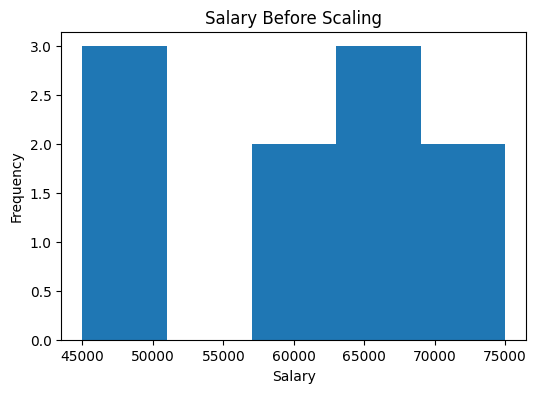

In [12]:
plt.figure(figsize=(6,4))

plt.hist(df["Salary"], bins=5)

plt.title("Salary Before Scaling")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

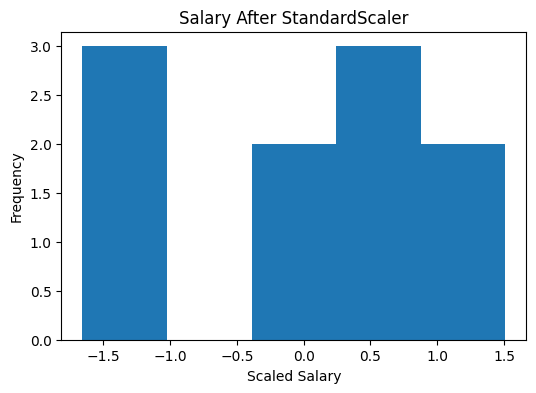

In [13]:
plt.figure(figsize=(6,4))

plt.hist(standard_df["Salary"], bins=5)

plt.title("Salary After StandardScaler")

plt.xlabel("Scaled Salary")

plt.ylabel("Frequency")

plt.show()

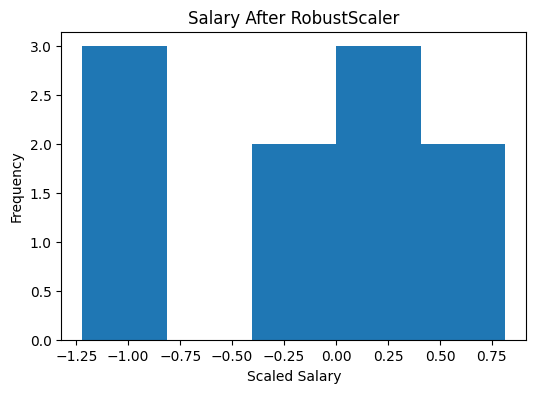

In [14]:
plt.figure(figsize=(6,4))

plt.hist(robust_df["Salary"], bins=5)

plt.title("Salary After RobustScaler")

plt.xlabel("Scaled Salary")

plt.ylabel("Frequency")

plt.show()

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

feature_df = label_df.copy()

X = feature_df.drop(columns=["Performance", "Name"])

y = feature_df["Performance"]

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")

print(selected_features)

Top 5 Features:
Index(['Department', 'City', 'Education', 'Experience', 'Salary'], dtype='object')


In [ ]:
Trade-offs of Encoding

1. LabelEncoder
- Simple and fast.
- May introduce an artificial order.

2. OneHotEncoder
- Avoids ordinal relationships.
- Increases the number of columns.

3. OrdinalEncoder
- Suitable only for ordered categories.

Scaling Methods

1. StandardScaler
- Centers data around mean 0 with standard deviation 1.

2. MinMaxScaler
- Scales values to the range [0,1].

3. RobustScaler
- Less affected by outliers than StandardScaler.

Top 5 Features

Experience:
Employees with more experience often have better performance.

Salary:
Higher salaries generally correspond to more senior roles.

Department:
Different departments may have different performance patterns.

City:
Location can influence work environment and opportunities.

Education:
Educational qualifications can contribute to employee performance.